In [1]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [2]:
import joblib
xgb_model = joblib.load("../models/xgboost.pkl")
print("XGBoost model loaded successfully!")

XGBoost model loaded successfully!


In [3]:
X_test = pd.read_csv("../data/processed/X_test_processed.csv")
print("X_test shape:", X_test.shape)

X_test shape: (1409, 45)


In [4]:
y_test = pd.read_csv("../data/processed/y_test.csv")
print("y_test shape:", y_test.shape)

y_test shape: (1409, 1)


In [5]:
X_test = X_test.reset_index(drop=True)
y_test = y_test.squeeze().reset_index(drop=True)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (1409, 45)
y_test: (1409,)


In [6]:
explainer = shap.TreeExplainer(xgb_model)
print("SHAP TreeExplainer created successfully!")

SHAP TreeExplainer created successfully!


In [7]:
shap_values = explainer.shap_values(X_test)
print("SHAP values calculated!")
print("SHAP values shape:", shap_values.shape)

SHAP values calculated!
SHAP values shape: (1409, 45)


In [8]:
feature_importance = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_Absolute_SHAP": feature_importance
})

shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

shap_importance.head(10)

,Feature,Mean_Absolute_SHAP
36,cat__Contract_Month-to-month,0.747055
1,num__tenure,0.482143
18,cat__OnlineSecurity_No,0.333336
16,cat__InternetService_Fiber optic,0.227606
43,cat__PaymentMethod_Electronic check,0.212186
27,cat__TechSupport_No,0.179027
2,num__MonthlyCharges,0.163367
35,cat__StreamingMovies_Yes,0.149458
39,cat__PaperlessBilling_No,0.126059
32,cat__StreamingTV_Yes,0.111076


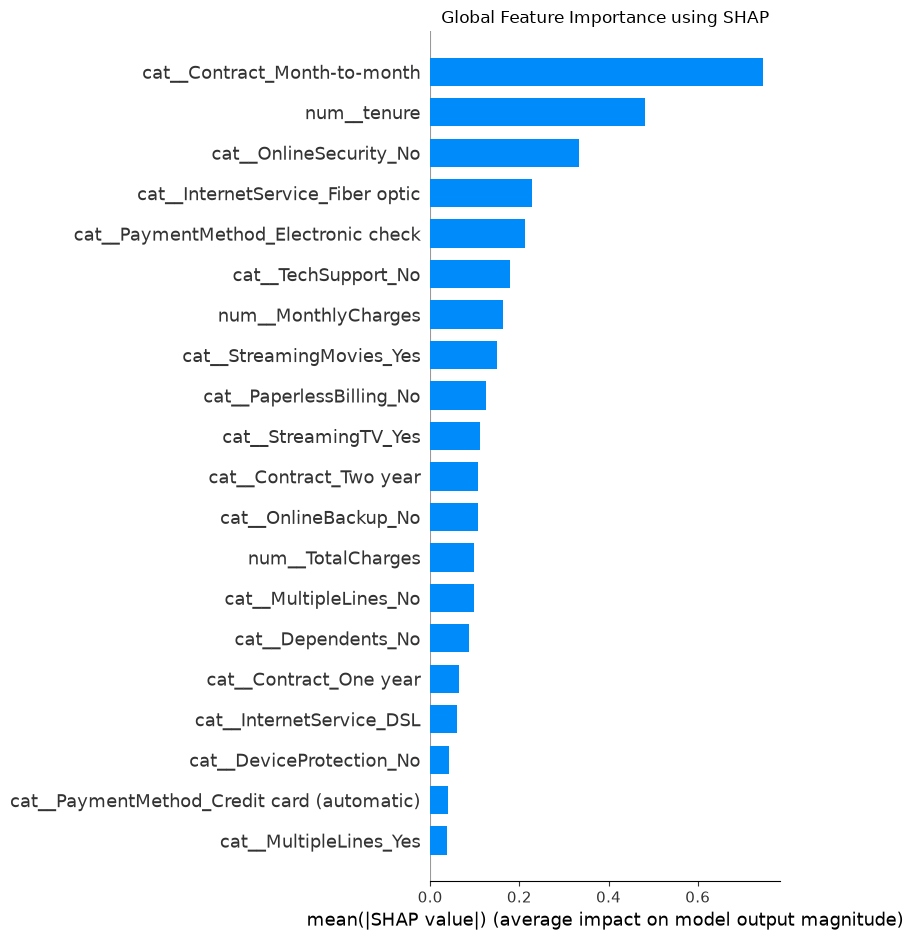

In [9]:
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.title("Global Feature Importance using SHAP")
plt.tight_layout()

plt.savefig(
    "../reports/figures/shap_summary_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
shap_importance.to_csv(
    "../reports/shap_feature_importance.csv",
    index=False
)

print("SHAP feature importance saved successfully!")

SHAP feature importance saved successfully!


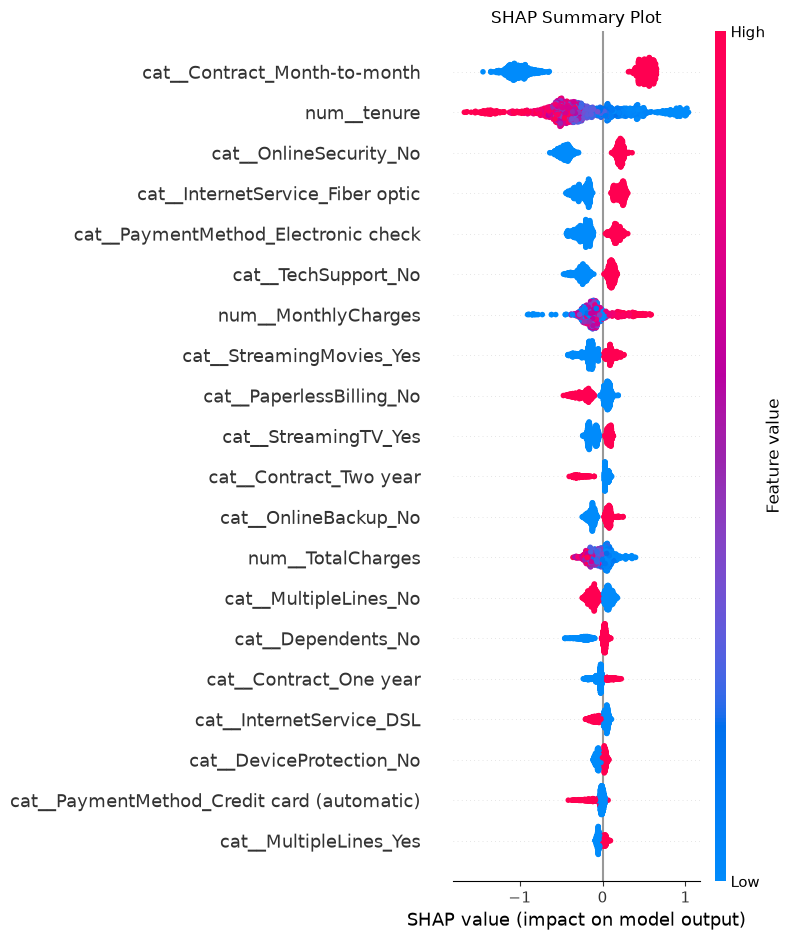

In [11]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.savefig(
    "../reports/figures/shap_summary_beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
import os

files_to_check = [
    "../reports/shap_feature_importance.csv",
    "../reports/figures/shap_summary_bar.png",
    "../reports/figures/shap_summary_beeswarm.png"
]

for file in files_to_check:
    print(file, "→", os.path.exists(file))

../reports/shap_feature_importance.csv → True
../reports/figures/shap_summary_bar.png → True
../reports/figures/shap_summary_beeswarm.png → True
